-Image-
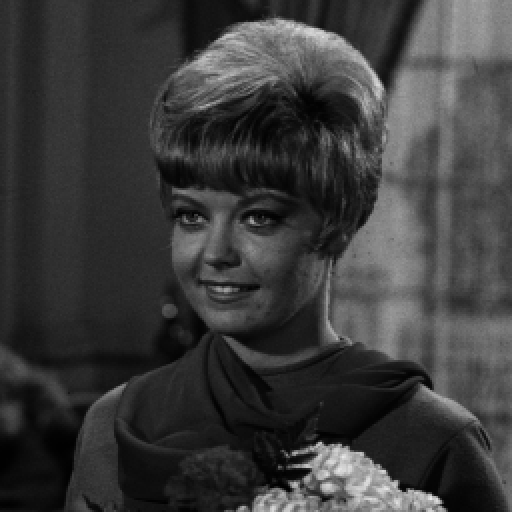

In [2]:
Module[{img, imgData},
  img = ColorConvert[ExampleData[{"TestImage", "Girl"}], "GrayScale"];
  imgData = ImageData[img, "Byte"];
  Image[imgData, "Byte"]
]

0     64    16    80    4     68    20    84    1     65    17    81    5     69
 
>    21    85

128   192   144   208   132   196   148   212   129   193   145   209   133   197
 
>       149   213

32    96    48    112   36    100   52    116   33    97    49    113   37    101
 
>    53    117

160   224   176   240   164   228   180   244   161   225   177   241   165   229
 
>       181   245

8     72    24    88    12    76    28    92    9     73    25    89    13    77
 
>    29    93

136   200   152   216   140   204   156   220   137   201   153   217   141   205
 
>       157   221

40    104   56    120   44    108   60    124   41    105   57    121   45    109
 
>    61    125

168   232   184   248   172   236   188   252   169   233   185   249   173   237
 
>       189   253

2     66    18    82    6     70    22    86    3     67    19    83    7     71
 
>    23    87

130   194   146   210   134   198   150   214   131   195   147   211   135   199
 
>       151   215

34    98    50    114   38    102   54    118   35    99    51    115   39    103
 
>    55    119

162   226   178   242   166   230   182   246   163   227   179   243   167   231
 
>       183   247

10    74    26    90    14    78    30    94    11    75    27    91    15    79
 
>    31    95

138   202   154   218   142   206   158   222   139   203   155   219   143   207
 
>       159   223

42    106   58    122   46    110   62    126   43    107   59    123   47    111
 
>    63    127

170   234   186   250   174   238   190   254   171   235   187   251   175   239
 
>       191   255
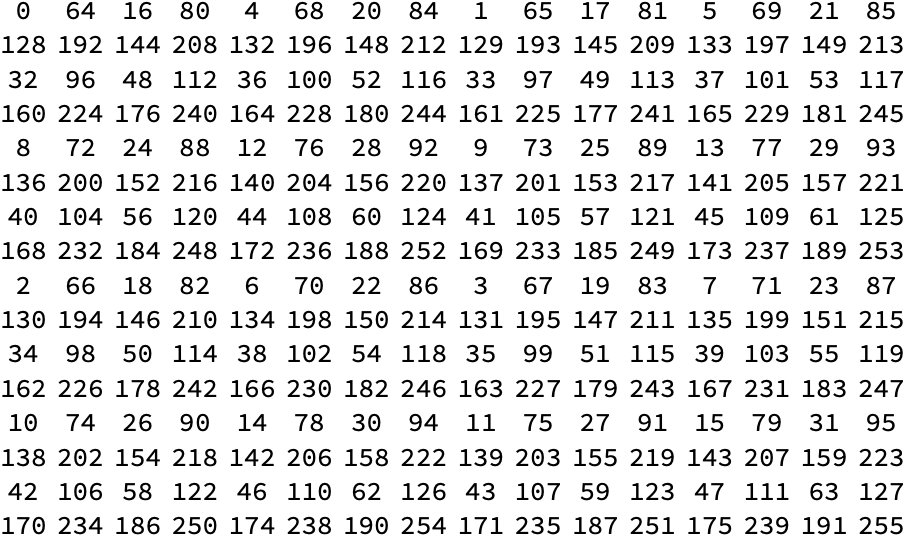

In [3]:
Module[{tbl},
  tbl = Partition[Range[256], 16];
  tbl = Map[IntegerDigits[# - 1, 2, 8] &, tbl, {-1}];
  tbl = Map[Join @@ (Reverse @ Transpose[Partition[#, 4]]) &, tbl, {-2}];
  tbl = Map[FromDigits[#, 2] &, tbl, {-2}];
  Grid[tbl]
]

In [235]:
encode[n_, bit_] := Module[{tmp},
  tmp = IntegerDigits[n, 2, bit];
  tmp = Partition[tmp, bit / 2];
  tmp = Transpose[tmp];
  tmp = Reverse[tmp];
  tmp = Join @@ tmp;
  tmp = FromDigits[tmp, 2];
  tmp
]

decode[n_, bit_] := Module[{tmp},
  tmp = IntegerDigits[n, 2, bit];
  tmp = Partition[tmp, 2];
  tmp = Reverse[tmp];
  tmp = Transpose[tmp];
  tmp = Join @@ tmp;
  tmp = FromDigits[tmp, 2];
  tmp
]

numToVec[n_, bit_] := Module[{tmp},
  tmp = IntegerDigits[n, 2, bit];
  tmp = Partition[tmp, bit / 2];
  tmp = FromDigits[#, 2] & /@ tmp;
  tmp
]

In [ ]:
{0, 0, 0, 1, 0, 0, 1, 0}
{{0, 0, 0, 1}, {0, 0, 1, 0}}
{{0, 0}, {0, 0}, {0, 1}, {1, 0}}
{{1, 0}, {0, 1}, {0, 0}, {0, 0}}
{1, 0, 0, 1, 0, 0, 0, 0}

In [ ]:
{1, 0, 0, 1, 0, 0, 0, 0}
{{1, 0}, {0, 1}, {0, 0}, {0, 0}}
{{0, 0}, {0, 0}, {0, 1}, {1, 0}}
{{0, 0, 0, 1}, {0, 0, 1, 0}}
{0, 0, 0, 1, 0, 0, 1, 0}

0     64    16    80    4     68    20    84    1     65    17    81    5     69
 
>    21    85

128   192   144   208   132   196   148   212   129   193   145   209   133   197
 
>       149   213

32    96    48    112   36    100   52    116   33    97    49    113   37    101
 
>    53    117

160   224   176   240   164   228   180   244   161   225   177   241   165   229
 
>       181   245

8     72    24    88    12    76    28    92    9     73    25    89    13    77
 
>    29    93

136   200   152   216   140   204   156   220   137   201   153   217   141   205
 
>       157   221

40    104   56    120   44    108   60    124   41    105   57    121   45    109
 
>    61    125

168   232   184   248   172   236   188   252   169   233   185   249   173   237
 
>       189   253

2     66    18    82    6     70    22    86    3     67    19    83    7     71
 
>    23    87

130   194   146   210   134   198   150   214   131   195   147   211   135   199
 
>       151   215

34    98    50    114   38    102   54    118   35    99    51    115   39    103
 
>    55    119

162   226   178   242   166   230   182   246   163   227   179   243   167   231
 
>       183   247

10    74    26    90    14    78    30    94    11    75    27    91    15    79
 
>    31    95

138   202   154   218   142   206   158   222   139   203   155   219   143   207
 
>       159   223

42    106   58    122   46    110   62    126   43    107   59    123   47    111
 
>    63    127

170   234   186   250   174   238   190   254   171   235   187   251   175   239
 
>       191   255
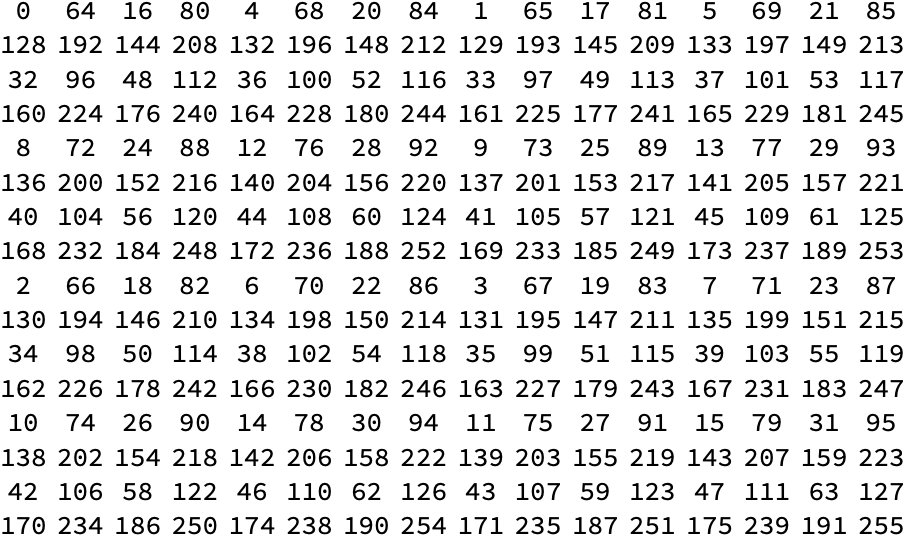

In [225]:
Grid[Partition[Table[encode[i, 8], {i, 0, 255}], 16]]

In [227]:
Table[decode[encode[i, 8], 8], {i, 0, 255}]

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 
 
>   24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 
 
>   45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 
 
>   66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 
 
>   87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 
 
>   106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 
 
>   123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 
 
>   140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 
 
>   157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 
 
>   174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 
 
>   191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 
 
>   208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 
 
>   225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 
 
>   242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255}